In [1]:
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

In [2]:
root = './data/'

## Wind data

In [3]:
# loading the wind data and saving it in a useful manner
wind = pd.read_csv(root+'windcapfac_model.csv', index_col=2)
wind['time'] = pd.to_datetime(wind.index, dayfirst=True) + pd.Timedelta(hours=-1)
wind = wind.set_index('time').sort_index()

# selecting time range 2015-2023 (9 years)
wind = wind.loc[pd.to_datetime('2015'):pd.to_datetime('2023-12-31 23')]

# creating datframe for processed wind data
wind_pro = pd.DataFrame()

# selecting all relevant fields
wind_pro.index      = wind.index
wind_pro['SWP']     = wind['cap_fac_SWP-25kW']/100
wind_pro['IceWind'] = wind['cap_fac_IceWind']/100

# saving to csv
wind_pro.to_csv(root+'isfjord_wind.csv')

## Load data

In [4]:
# import Dataset
data = xr.open_dataset(root+'./data_isfjord.nc').load()

# create 365 days of data from 07/23-06/24 - all parameters available
data_yr = xr.merge([data.shift(time=-8760).sel(time=slice('01-2023','06-2023')),data.sel(time=slice('07-2023','12-2023'))])

# filte unreasonable values from thermal prduction, consumption and consumed electricity
data_yr['cte'].values = xr.where(data_yr.cte >=5, data_yr.cte, np.nan)
data_yr['cte'].values = xr.where(data_yr.cte <=60, data_yr.cte, np.nan).interpolate_na(dim='time', method='linear', fill_value='extrapolate')
data_yr['pte'].values = xr.where(data_yr.pte <=120, data_yr.pte, np.nan).interpolate_na(dim='time', method='linear', fill_value='extrapolate')
data_yr['cee'].values = xr.where(data_yr.cee >=15, data_yr.cee, np.nan).interpolate_na(dim='time', method='linear', fill_value='extrapolate')

### correct the consumed electric energy for use of boiler
# compute weekly values
data_wk = data_yr.groupby('time.week').sum()

# weekly factors to correct boiler production - weekly overshoot divided by hours of week
deduction = xr.where((data_wk.cte-data_wk.pte)/(7*24)>=0, (data_wk.cte-data_wk.pte)/(7*24), 0)

# broadcast weekly data to hourly resolution
deduction_hourly = np.concatenate([np.zeros(24),np.outer(deduction.values, np.ones(7*24)).flatten()])

# deduct from hourly electricity consumption
data_yr['cee_c'] = data_yr.cee-deduction_hourly

/home/anton/anaconda3/envs/spyder-env/lib/python3.10/site-packages/xarray/core/accessor_dt.py:441: FutureWarning: dt.weekofyear and dt.week have been deprecated. Please use dt.isocalendar().week instead.
  warnings.warn(


In [5]:
# extrapolate the one year dataset to nine years
time_ext = pd.date_range(start='2015-01-01', end='2023-12-31 23:00', freq='h')
cee_ext  = np.tile(data_yr.cee_c, 10)[:len(time_ext)]
cte_ext  = np.tile(data_yr.cte, 10)[:len(time_ext)]

# add noise to account for variations
cee_ext_noisy = cee_ext + np.random.normal(loc=0, scale=0.10 * cee_ext, size=cee_ext.shape) # 10% noise for electric consumption
cte_ext_noisy = cte_ext + np.random.normal(loc=0, scale=0.20 * cte_ext, size=cte_ext.shape) # 20% noise for thermal consumption

# again filter for values outside the expected range
cte_ext_noisy = np.where(cte_ext_noisy >=5, cte_ext_noisy, np.nan)
cte_ext_noisy = np.where(cte_ext_noisy <=60, cte_ext_noisy, np.nan)
ds_cte        = xr.Dataset({'cte': (['time'], cte_ext_noisy)}, coords={'time': time_ext}).interpolate_na(dim='time', method='linear', fill_value='extrapolate')
cee_ext_noisy = np.where(cee_ext_noisy >=15, cee_ext_noisy, np.nan)
ds_cee        = xr.Dataset({'cee': (['time'], cee_ext_noisy)}, coords={'time': time_ext}).interpolate_na(dim='time', method='linear', fill_value='extrapolate')

In [6]:
# create pandas data frame and save load data
load = pd.DataFrame()

# selecting all relevant fields
load.index        = time_ext
load['AC load']   = ds_cee.cee.values
load['heat load'] = ds_cte.cte.values

# saving to csv
load.to_csv(root+'isfjord_load.csv')

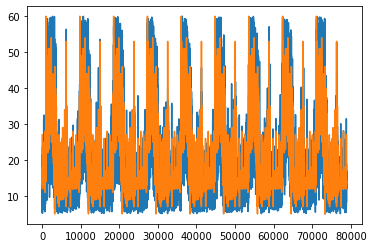

In [7]:
plt.plot(cte_ext_noisy)
plt.plot(cte_ext)
plt.show()

## Solar data

In [8]:
# loading the solar data and saving it in a useful manner
solar_r         = pd.read_csv(root+'roof_input_capacity_factor.csv', index_col=0)
solar_r['time'] = pd.to_datetime(solar_r.index, yearfirst=True)
solar_r         = solar_r.set_index('time').sort_index()

solar_p         = pd.read_csv(root+'park_input_capacity_factor.csv', index_col=0)
solar_p['time'] = pd.to_datetime(solar_p.index, yearfirst=True)
solar_p         = solar_p.set_index('time').sort_index()

In [9]:
# extrapolate the one year dataset to nine years
solar_r_ext  = np.tile(solar_r['av_cf_roof'], 10)[:len(time_ext)]
solar_p_ext  = np.tile(solar_p['av_cf_park'], 10)[:len(time_ext)]

# add noise to account for variations
solar_r_ext_noisy = solar_r_ext + np.random.normal(loc=0, scale=0.40 * solar_r_ext, size=solar_r_ext.shape) # 40% noise for roof installation
solar_p_ext_noisy = solar_p_ext + np.random.normal(loc=0, scale=0.60 * solar_p_ext, size=solar_p_ext.shape) # 60% noise for park installation

# again filter for values outside the expected range
solar_r_ext_noisy = np.where(solar_r_ext_noisy >=0, solar_r_ext_noisy, np.nan)
solar_r_ext_noisy = np.where(solar_r_ext_noisy <=.5, solar_r_ext_noisy, np.nan)
ds_solar_r        = xr.Dataset({'sol': (['time'], solar_r_ext_noisy)}, coords={'time': time_ext}).interpolate_na(dim='time', method='linear', fill_value='extrapolate')
solar_p_ext_noisy = np.where(solar_p_ext_noisy <=1, solar_p_ext_noisy, np.nan)
solar_p_ext_noisy = np.where(solar_p_ext_noisy >=0, solar_p_ext_noisy, np.nan)
ds_solar_p        = xr.Dataset({'sol': (['time'], solar_p_ext_noisy)}, coords={'time': time_ext}).interpolate_na(dim='time', method='linear', fill_value='extrapolate')

In [10]:
# create pandas data frame and save solar data
solar = pd.DataFrame()

# selecting all relevant fields
solar.index   = time_ext
solar['roof'] = ds_solar_r.sol.values
solar['park'] = ds_solar_p.sol.values

# saving to csv
solar.to_csv(root+'isfjord_solar.csv')